# Weighted Categorical Cross‑Entropy

In [1]:
import tensorflow as tf
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, recall_score
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pathlib
import pickle

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

2026-06-08 06:28:27.750515: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-08 06:28:27.750624: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-08 06:28:27.754699: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-08 06:28:27.771122: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3050 Laptop GPU, compute capability 8.6


2026-06-08 06:28:29.933174: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-08 06:28:29.956078: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-08 06:28:29.956134: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-08 06:28:29.956484: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


TensorFlow version: 2.15.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
organized_base = pathlib.Path("/tf/work/data/organized_dataset")
train_dir = organized_base / "Train"
val_dir = organized_base / "Validation"
test_dir = organized_base / "Test"

IMG_SIZE = (128, 128)
BATCH_SIZE = 8

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_gen = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"Train: {train_gen.samples}, Val: {val_gen.samples}, Test: {test_gen.samples}")

Found 49376 images belonging to 15 classes.
Found 10584 images belonging to 15 classes.
Found 10589 images belonging to 15 classes.
Train: 49376, Val: 10584, Test: 10589


In [3]:
class_names = list(train_gen.class_indices.keys())
classes = np.unique(train_gen.classes)
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_gen.classes
)
class_weights_list = class_weights_array.tolist()

print("Class weights (higher = more important):")
for name, w in zip(class_names, class_weights_list):
    print(f"   {name}: {w:.4f}")

Class weights (higher = more important):
   Apple: 0.4205
   Banana: 1.5542
   Carambola: 2.2608
   Guava: 0.2387
   Kiwi: 0.5556
   Mango: 1.1323
   Orange: 1.5615
   Peach: 1.7890
   Pear: 1.5615
   Persimmon: 2.2702
   Pitaya: 1.8810
   Plum: 2.0471
   Pomegranate: 2.1713
   Tomatoes: 2.1670
   muskmelon: 2.2639


In [4]:
class WeightedCategoricalCrossentropy(tf.keras.losses.Loss):
    def __init__(self, class_weights, name="weighted_categorical_crossentropy"):
        super().__init__(name=name)
        self.class_weights = tf.constant(class_weights, dtype=tf.float32)

    def call(self, y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        loss = -tf.reduce_sum(y_true * tf.math.log(y_pred + epsilon), axis=-1)
        y_true_classes = tf.argmax(y_true, axis=-1)
        weights = tf.gather(self.class_weights, y_true_classes)
        weighted_loss = loss * weights
        return tf.reduce_mean(weighted_loss)

custom_loss = WeightedCategoricalCrossentropy(class_weights_list)

2026-06-08 06:28:33.147924: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-08 06:28:33.148054: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-08 06:28:33.148169: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-08 06:28:33.361877: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-08 06:28:33.361956: I external/local_xla/xla/stream_executor

In [5]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
base_model.trainable = False

inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(train_gen.num_classes, activation='softmax', dtype='float32')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss=custom_loss,
    metrics=['accuracy']
)

model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 vgg16 (Functional)          (None, 4, 4, 512)         14714688  
                                                                 
 global_average_pooling2d (  (None, 512)               0         
 GlobalAveragePooling2D)                                         
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense (Dense)               (None, 15)                7695      
                                                                 
Total params: 14722383 (56.16 MB)
Trainable params: 7695 (30.06 KB)
Non-trainable params: 14714688 (56.13 MB)
_________________

In [6]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7, verbose=1)
]

history = model.fit(
    train_gen,
    steps_per_epoch=train_gen.samples // BATCH_SIZE,
    epochs=20,
    validation_data=val_gen,
    validation_steps=val_gen.samples // BATCH_SIZE,
    callbacks=callbacks,
    workers=4,
    use_multiprocessing=True
)

with open('history_weighted.pkl', 'wb') as f:
    pickle.dump(history.history, f)

Epoch 1/20


2026-06-08 06:28:35.512101: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8906
2026-06-08 06:28:37.276882: I external/local_xla/xla/service/service.cc:168] XLA service 0x770a7e1bb710 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-06-08 06:28:37.276953: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2026-06-08 06:28:37.300614: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780900117.425026    3376 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


6172/6172 [==============================] - 206s 33ms/step - loss: 2.2667 - accuracy: 0.3155 - val_loss: 1.7268 - val_accuracy: 0.5832 - lr: 1.0000e-04
Epoch 2/20
6172/6172 [==============================] - 208s 34ms/step - loss: 1.6721 - accuracy: 0.5312 - val_loss: 1.3380 - val_accuracy: 0.6584 - lr: 1.0000e-04
Epoch 3/20
6172/6172 [==============================] - 210s 34ms/step - loss: 1.4031 - accuracy: 0.5950 - val_loss: 1.1293 - val_accuracy: 0.6910 - lr: 1.0000e-04
Epoch 4/20
6172/6172 [==============================] - 209s 34ms/step - loss: 1.2396 - accuracy: 0.6305 - val_loss: 0.9904 - val_accuracy: 0.7139 - lr: 1.0000e-04
Epoch 5/20
6172/6172 [==============================] - 211s 34ms/step - loss: 1.1302 - accuracy: 0.6515 - val_loss: 0.8904 - val_accuracy: 0.7398 - lr: 1.0000e-04
Epoch 6/20
6172/6172 [==============================] - 209s 34ms/step - loss: 1.0560 - accuracy: 0.6612 - val_loss: 0.8211 - val_accuracy: 0.7520 - lr: 1.0000e-04
Epoch 7/20
6172/6172 [=====

In [7]:
test_loss, test_acc = model.evaluate(test_gen, workers=4, use_multiprocessing=True)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

1324/1324 [==============================] - 34s 26ms/step - loss: 0.5015 - accuracy: 0.8175
Test Accuracy: 0.8175
Test Loss: 0.5015


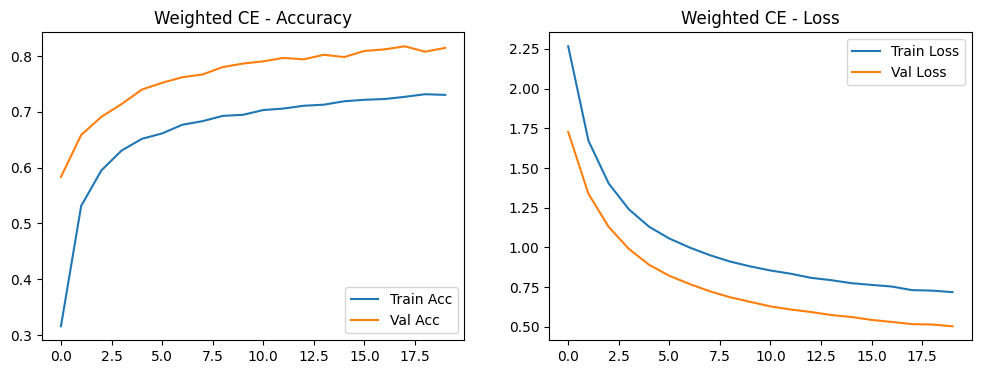

In [8]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Weighted CE - Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Weighted CE - Loss')
plt.legend()
plt.show()

1324/1324 [==============================] - 108s 81ms/step

CLASSIFICATION REPORT – WEIGHTED CE
              precision    recall  f1-score   support

       Apple     0.8612    0.3403    0.4878      1678
      Banana     0.9824    0.9802    0.9813       455
   Carambola     0.9651    0.9744    0.9697       312
       Guava     0.9336    0.9188    0.9261      2955
        Kiwi     0.8463    0.9409    0.8911      1270
       Mango     0.8605    0.7612    0.8078       624
      Orange     0.7128    0.9226    0.8042       452
       Peach     0.6391    0.9190    0.7539       395
        Pear     0.6337    0.7080    0.6688       452
   Persimmon     0.8559    0.9550    0.9027       311
      Pitaya     0.9613    0.9920    0.9764       376
        Plum     0.9635    0.9942    0.9786       345
 Pomegranate     0.6326    0.8344    0.7196       326
    Tomatoes     0.4515    0.8988    0.6010       326
   muskmelon     0.5952    0.8718    0.7074       312

    accuracy                         

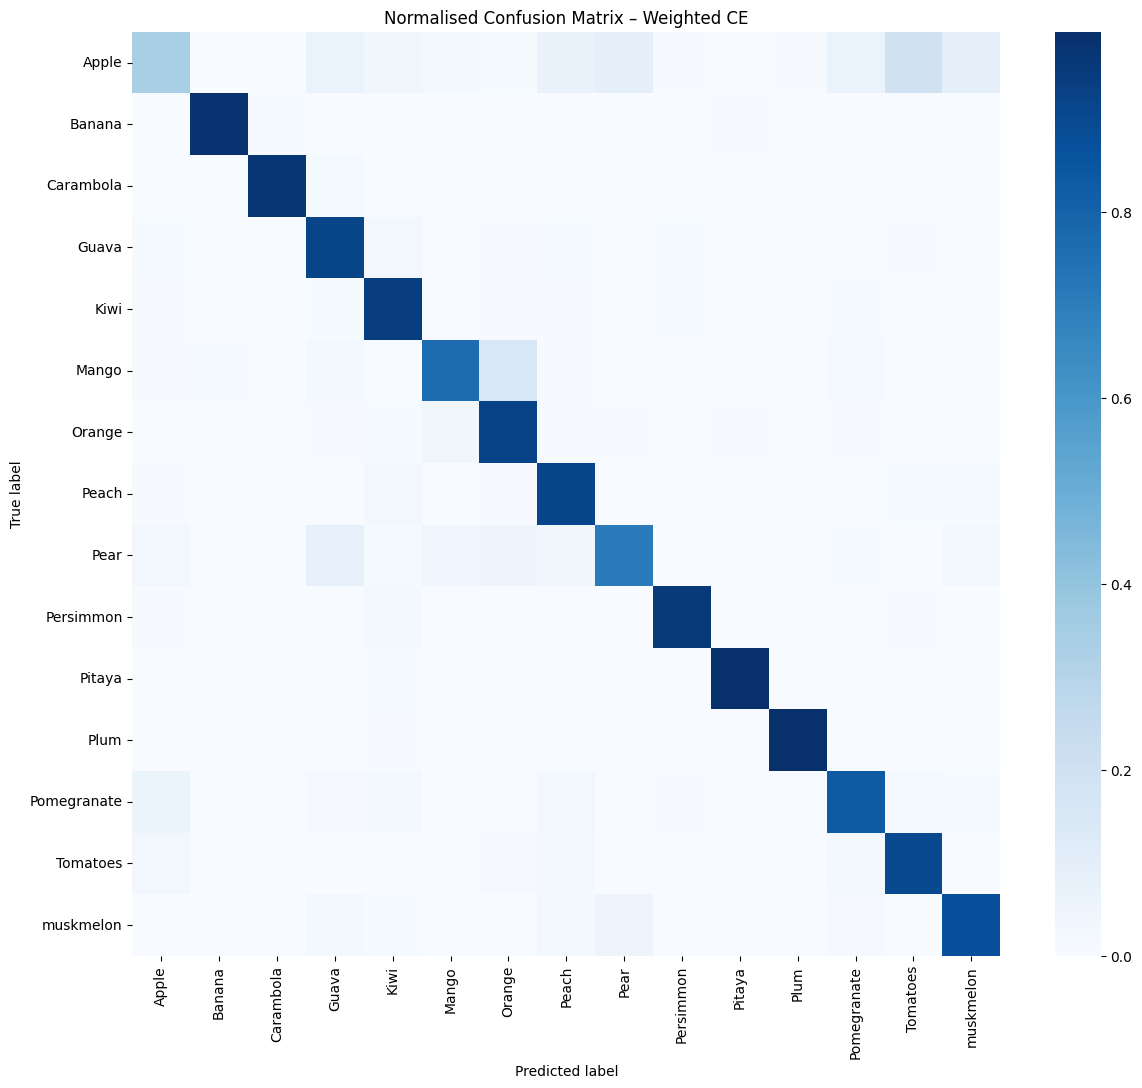

In [9]:
y_pred_probs = model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

print("\n" + "="*60)
print("CLASSIFICATION REPORT – WEIGHTED CE")
print("="*60)
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report)

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(14,12))
sns.heatmap(cm_norm, annot=False, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Normalised Confusion Matrix – Weighted CE')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [10]:
class_counts = [np.sum(train_gen.classes == i) for i in range(len(class_names))]
recalls = recall_score(y_true, y_pred, average=None)
minority_threshold = 2000
minority_indices = [i for i, cnt in enumerate(class_counts) if cnt < minority_threshold]
minority_recalls = [recalls[i] for i in minority_indices]

print(f"\nMinority classes (<{minority_threshold} images):")
for idx in minority_indices:
    print(f"  {class_names[idx]}: recall = {recalls[idx]:.4f}")
print(f"\nAverage recall on minority classes: {np.mean(minority_recalls):.3f}")
print(f"Average recall on majority classes: {np.mean([recalls[i] for i, cnt in enumerate(class_counts) if cnt >= minority_threshold]):.3f}")


Minority classes (<2000 images):
  Carambola: recall = 0.9744
  Peach: recall = 0.9190
  Persimmon: recall = 0.9550
  Pitaya: recall = 0.9920
  Plum: recall = 0.9942
  Pomegranate: recall = 0.8344
  Tomatoes: recall = 0.8988
  muskmelon: recall = 0.8718

Average recall on minority classes: 0.930
Average recall on majority classes: 0.796


In [11]:
misclassified_indices = np.where(y_pred != y_true)[0]
confusion_pairs = [(y_true[i], y_pred[i]) for i in misclassified_indices]
pair_counts = Counter(confusion_pairs)

print("\n" + "="*60)
print("TOP 5 MOST CONFUSED FRUIT PAIRS (true → predicted)")
print("="*60)
for (true, pred), count in pair_counts.most_common(5):
    print(f"{class_names[true]:15s} → {class_names[pred]:15s} : {count} errors")


TOP 5 MOST CONFUSED FRUIT PAIRS (true → predicted)
Apple           → Tomatoes        : 328 errors
Apple           → Pear            : 154 errors
Apple           → muskmelon       : 152 errors
Apple           → Peach           : 119 errors
Apple           → Pomegranate     : 109 errors


In [12]:
metrics = {
    'classification_report': report,
    'confusion_matrix': cm,
    'class_names': class_names,
    'class_counts': class_counts,
    'minority_recalls': minority_recalls,
    'confusion_pairs': pair_counts.most_common(10)
}
with open('weighted_metrics.pkl', 'wb') as f:
    pickle.dump(metrics, f)
print("Metrics saved to 'weighted_metrics.pkl'")

Metrics saved to 'weighted_metrics.pkl'
